This notebook studies how diversification changes the risk-return trade-off, starting with two assets and ending with a CAPM illustration.

Notebook roadmap:
1. Start with two stocks and see how changing the portfolio weight moves us through mean-volatility space.
2. Add a third stock and interpret the feasible set through the simplex of admissible weights.
3. Scale up to 30 stocks, first by numerical sampling and then by Markowitz optimization.
4. Study how volatility falls as more stocks are added to an equal-weight portfolio.
5. Close with CAPM beta estimation and a Security Market Line plot.

### Return convention used in this notebook:
- In the risk and portfolio sections we work with daily log returns, $\ell_t = \log(P_t/P_{t-1})$.
- We annualize the sample mean and volatility of those daily log returns using 252 trading days:
$$
\mu_{\text{ann}} \approx 252\,\bar\ell,
\qquad
\sigma_{\text{ann}} \approx \sqrt{252}\,s(\ell).
$$
- When we write portfolio formulas such as $\mu_p \approx w^\top \mu$ and $\sigma_p^2 \approx w^\top \Sigma w$, interpret them as the standard daily-return approximation based on log-return moments.
- In the CAPM section we switch back to simple excess returns, because the textbook CAPM regression and the Security Market Line are normally stated in simple-return terms.

### **Notation used throughout the notebook:**
- $P_t$: adjusted price at date $t$.
- $r_t$: simple return, $r_t = \dfrac{P_t-P_{t-1}}{P_{t-1}}$.
- $\ell_t$: log return, $\ell_t = \log\!\left(\dfrac{P_t}{P_{t-1}}\right)=\log(1+r_t)$.
- $\bar\ell$: sample mean of log returns.
- $s(\ell)$: sample standard deviation of log returns.
- $\mu$: expected return input used in the mean-volatility sections.
- $\sigma$: return volatility.
- $w_i$: portfolio weight on asset $i$, with $\sum_i w_i = 1$.

## Setup and Data Download

The next code cell does the full data setup for the notebook:
- imports the numerical, plotting, optimization, and data-download packages,
- defines the date window and the 30-stock universe,
- downloads adjusted close prices from Yahoo Finance via `yfinance`,
- caches the result to `30_stock_prices.csv`, and
- displays `prices.head()` so we can verify that the panel loaded correctly.

The current parameter values in code are:
- Start date: `2018-01-01`
- End date (exclusive): `today`

If a cached CSV already exists, the code reuses it instead of downloading again.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Finance data source
import yfinance as yf

# Optimization / geometry helpers used later in the notebook
from scipy.optimize import minimize
from scipy.spatial import ConvexHull
import itertools
from pathlib import Path

# -----------------------------
# User-set parameters
# -----------------------------
DATA_START = "2018-01-01"
DATA_END = None  # None means "up to the latest available date"

TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "NVDA", "META", "JPM", "PG", "UNH",
    "DIS", "HD", "V", "MA", "PFE", "KO", "PEP", "INTC", "CSCO", "BA",
    "MMM", "CVX", "XOM", "T", "WMT", "IBM", "ADBE", "NFLX", "ORCL", "MRK"
]

PRICES_CSV = "30_stock_prices.csv"

def _extract_close_prices(raw_download):
    """
    Return a DataFrame of close prices from yfinance output.
    yfinance can return either a normal column index or a MultiIndex.
    """
    if raw_download.empty:
        raise ValueError("yfinance returned no data. Check dates, tickers, or internet connection.")

    if isinstance(raw_download.columns, pd.MultiIndex):
        top_level = raw_download.columns.get_level_values(0)
        if "Close" in top_level:
            prices = raw_download["Close"]
        elif "Adj Close" in top_level:
            prices = raw_download["Adj Close"]
        else:
            raise KeyError("Could not find 'Close' or 'Adj Close' in downloaded data.")
    else:
        if "Close" in raw_download.columns:
            prices = raw_download[["Close"]]
        elif "Adj Close" in raw_download.columns:
            prices = raw_download[["Adj Close"]]
        else:
            raise KeyError("Could not find 'Close' or 'Adj Close' in downloaded data.")

    if isinstance(prices, pd.Series):
        prices = prices.to_frame()

    prices = prices.sort_index().dropna(how="all")
    return prices

def download_prices(tickers, start=DATA_START, end=DATA_END, csv_path=PRICES_CSV, force_download=False):
    """
    Download close prices and cache them to CSV.
    If cache exists and force_download=False, data is loaded from disk.
    """
    csv_path = Path(csv_path)

    if csv_path.exists() and not force_download:
        prices = pd.read_csv(csv_path, index_col="Date", parse_dates=True).sort_index()
        print(f"Loaded cached prices from '{csv_path.name}'")
        return prices

    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
    prices = _extract_close_prices(raw)

    # If yfinance returns fewer tickers than requested, warn the user.
    requested = set(tickers if isinstance(tickers, (list, tuple, pd.Index)) else [tickers])
    downloaded = set(prices.columns)
    missing = sorted(requested - downloaded)
    if missing:
        print(f"Warning: no data returned for {missing}")

    prices.to_csv(csv_path, index_label="Date")
    print(f"Data downloaded and saved as '{csv_path.name}'")
    return prices

# Download (or load cached) price data
prices = download_prices(TICKERS)
prices.head()


Data downloaded and saved as '30_stock_prices.csv'


Ticker,AAPL,ADBE,AMZN,BA,CSCO,CVX,DIS,GOOGL,HD,IBM,...,ORCL,PEP,PFE,PG,T,TSLA,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.304176,177.699997,59.450500,282.886383,30.433546,89.452377,106.224518,53.220631,153.792938,103.412827,...,41.251194,91.602783,23.830416,72.824982,16.087725,21.368668,193.090439,108.111923,28.855200,58.580421
2018-01-03,40.297153,181.039993,60.209999,283.801239,30.676331,90.104446,106.680595,54.128628,154.594482,106.255440,...,42.206612,91.362274,24.006989,72.736610,15.716213,21.150000,195.115997,109.188194,29.106907,59.730946
2018-01-04,40.484333,183.220001,60.479500,282.724396,30.763124,89.823990,106.633087,54.338890,155.821350,108.407455,...,42.622406,91.812294,24.059299,73.250771,15.862313,20.974667,195.962875,109.594193,29.133236,59.813633
2018-01-05,40.945255,185.339996,61.457001,294.322327,31.189178,89.676743,106.053513,55.059437,157.448990,108.937126,...,42.878948,92.076096,24.105080,73.298996,15.920755,21.105333,199.699677,112.218872,29.305923,59.765396
2018-01-08,40.793179,185.039993,62.343498,295.570740,31.512674,90.118477,104.533302,55.253826,157.072723,109.594116,...,43.330128,91.548477,23.836960,73.684586,15.966673,22.427334,196.233505,112.672043,29.739082,60.034081


### From Prices to Returns

The next code cell converts adjusted prices into return series in two ways:
- `simple_returns_daily`, which keeps the exact one-period return definition,
- `log_returns_daily`, which is the main object used in the risk and portfolio sections.

We use log returns because they are standard in finance for time-series work and additive across time:
$$
\ell_t = \log\!\left(\frac{P_t}{P_{t-1}}\right)=\log(1+r_t).
$$

The code then sets `returns_daily = log_returns_daily` so that the rest of the mean-volatility analysis uses log returns by default. Finally, it annualizes the sample mean and standard deviation of those daily log returns.

### Notation Used in the Mean-Volatility Sections

The portfolio-risk sections below use the following objects:
- $r_t = P_t/P_{t-1}-1$: simple daily return.
- $\ell_t = \log(P_t/P_{t-1}) = \log(1+r_t)$: log daily return.
- $\ell_{i,t}$: log return of asset $i$ on day $t$.
- $\mu_i$: annualized mean log return of asset $i$.
- $\sigma_i$: annualized volatility of asset $i$.
- $\Sigma$: annualized covariance matrix of daily log returns.
- $w_i$: portfolio weight on asset $i$, with $\sum_i w_i = 1$.

For exact one-period portfolio aggregation, simple returns satisfy $r_{p,t}=\sum_i w_i r_{i,t}$. In the mean-volatility sections we use the standard daily approximation
$$
\ell_{p,t} \approx w^\top \ell_t,
\qquad
\mu_p \approx w^\top \mu,
\qquad
\sigma_p^2 \approx w^\top \Sigma w,
$$
which is the convention implemented in the code below.

In [ ]:
# 1) Daily simple returns: R_t = P_t / P_{t-1} - 1
simple_returns_daily = prices.pct_change().dropna(how="all")

# 2) Daily log returns: r_t = ln(1 + R_t)
# Log returns are convenient because they add nicely over time.
log_returns_daily = np.log1p(simple_returns_daily)
log_returns_daily = log_returns_daily.replace([np.inf, -np.inf], np.nan).dropna(how="all")

# Main return object used in the risk/portfolio sections
returns_daily = log_returns_daily.copy()

# 3) Annualize mean and volatility from daily log returns
TRADING_DAYS_PER_YEAR = 252
mu_ann = returns_daily.mean() * TRADING_DAYS_PER_YEAR
sigma_ann = returns_daily.std() * np.sqrt(TRADING_DAYS_PER_YEAR)

summary_table = pd.DataFrame(
    {
        "annualized_mean_log_return": mu_ann,
        "annualized_volatility": sigma_ann,
    }
)
summary_table.head()

,annualized_mean_log_return,annualized_volatility
Ticker,,
AAPL,0.224951,0.306054
ADBE,0.036914,0.362676
AMZN,0.153491,0.342896
BA,-0.045199,0.448562
CSCO,0.122009,0.268611


## 1) Two Stocks: Risk-Return as Two Points

We now choose two names from the 30-stock universe and summarize each one by:
- its annualized mean log return, and
- its annualized volatility.

The next code cell extracts those two values for `AAPL` and `MSFT`, plots the two assets as points in mean-volatility space, and prints the corresponding series so the numerical values are visible as well.## 1) Two Stocks: Risk-Return as Two Points

We now choose two names from the 30-stock universe and summarize each one by:
- its annualized mean log return, and
- its annualized volatility.

The next code cell extracts those two values for `AAPL` and `MSFT`, plots the two assets as points in mean-volatility space, and prints the corresponding series so the numerical values are visible as well.

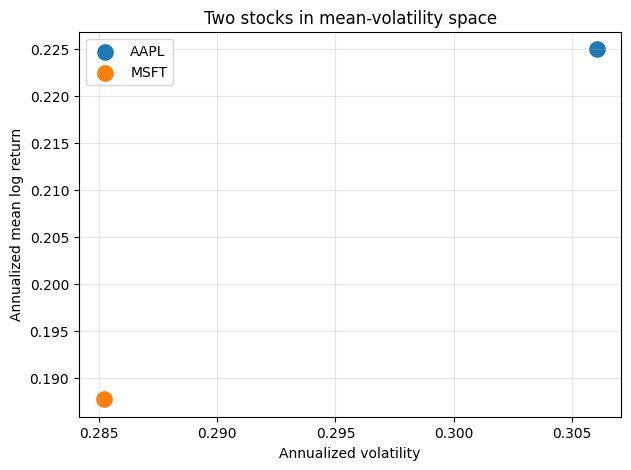

(Ticker
 AAPL    0.224951
 MSFT    0.187741
 dtype: float64,
 Ticker
 AAPL    0.306054
 MSFT    0.285190
 dtype: float64)

In [ ]:
# Choose two stocks for a first visual in mean-volatility space
stock1 = "AAPL"
stock2 = "MSFT"

# Keep only these two assets from the annualized vectors
mu2 = mu_ann[[stock1, stock2]]
sig2 = sigma_ann[[stock1, stock2]]

plt.figure(figsize=(7, 5))
plt.scatter(sig2[stock1], mu2[stock1], s=120, label=stock1)
plt.scatter(sig2[stock2], mu2[stock2], s=120, label=stock2)
plt.xlabel("Annualized volatility")
plt.ylabel("Annualized mean log return")
plt.title("Two stocks in mean-volatility space")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

mu2, sig2

## 2) Two Stocks: 50/50 Portfolio

With weights $(w,1-w)$ on the two assets, the code uses the annualized mean vector and covariance matrix of daily log returns to approximate the portfolio moments.

For daily returns this gives the familiar mean-volatility formulas:
$$
\mu_p(w) \approx w\mu_1 + (1-w)\mu_2,
$$
$$
\sigma_p^2(w) \approx w^2\sigma_1^2 + (1-w)^2\sigma_2^2 + 2w(1-w)\sigma_{12},
$$
where $\sigma_{12}=\operatorname{Cov}(\ell_1,\ell_2)$ on the annualized scale.

The next code cell:
- builds the annualized covariance matrix for `AAPL` and `MSFT`,
- defines a helper function that maps a weight into approximate portfolio mean and volatility,
- evaluates the special case $w=0.5$, and
- plots the two assets together with the 50/50 portfolio point.

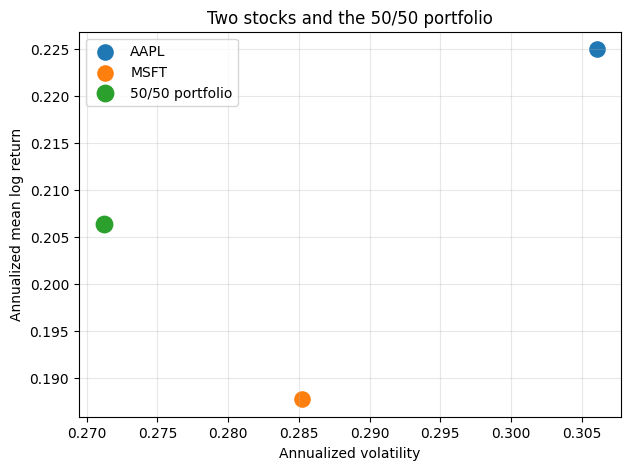

Annualized covariance Cov(AAPL,MSFT) = 0.059598
50/50 portfolio: mean log return = 0.2063, volatility = 0.2712


In [ ]:
# Annualized covariance matrix for the two selected stocks
cov2_ann = returns_daily[[stock1, stock2]].cov() * 252
cov12_ann = cov2_ann.loc[stock1, stock2]

def portfolio_mu_sigma_two(w, mu, cov):
    """
    Compute annualized portfolio mean return and volatility for 2 assets.

    Parameters
    ----------
    w : float
        Weight on asset 1 (asset 2 gets 1-w).
    mu : pd.Series
        Annualized expected returns of the two assets.
    cov : pd.DataFrame
        Annualized covariance matrix of the two assets.
    """
    w = float(w)
    if not 0 <= w <= 1:
        raise ValueError("For this section, w must be between 0 and 1 (long-only portfolio).")

    weights = np.array([w, 1 - w])
    mu_p = float(weights @ mu.values)
    var_p = float(weights @ cov.values @ weights)
    sig_p = np.sqrt(max(var_p, 0.0))
    return mu_p, sig_p

# Example: 50/50 portfolio
w = 0.5
mu_5050, sig_5050 = portfolio_mu_sigma_two(w, mu2, cov2_ann)

plt.figure(figsize=(7, 5))
plt.scatter(sig2[stock1], mu2[stock1], s=120, label=stock1)
plt.scatter(sig2[stock2], mu2[stock2], s=120, label=stock2)
plt.scatter(sig_5050, mu_5050, s=140, label="50/50 portfolio")
plt.xlabel("Annualized volatility")
plt.ylabel("Annualized mean log return")
plt.title("Two stocks and the 50/50 portfolio")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f"Annualized covariance Cov({stock1},{stock2}) = {cov12_ann:.6f}")
print(f"50/50 portfolio: mean log return = {mu_5050:.4f}, volatility = {sig_5050:.4f}")

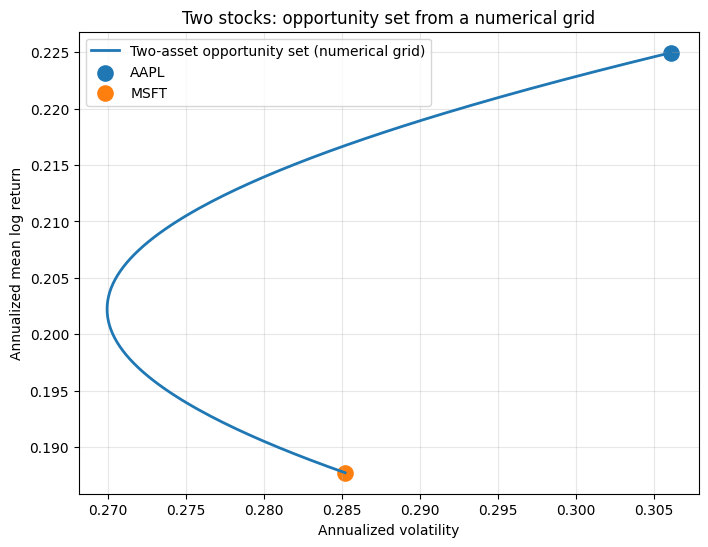

Number of grid points used for w: 201


In [ ]:
# Numerical grid of long-only weights (w from 0 to 1)
W = np.linspace(0, 1, 201)
mus = []
sigs = []

for w in W:
    mu_p, sig_p = portfolio_mu_sigma_two(w, mu2, cov2_ann)
    mus.append(mu_p)
    sigs.append(sig_p)

mus = np.array(mus)
sigs = np.array(sigs)

plt.figure(figsize=(8, 6))
plt.plot(sigs, mus, linewidth=2, label="Two-asset opportunity set (numerical grid)")
plt.scatter(sig2[stock1], mu2[stock1], s=120, label=stock1)
plt.scatter(sig2[stock2], mu2[stock2], s=120, label=stock2)
plt.xlabel("Annualized volatility")
plt.ylabel("Annualized mean log return")
plt.title("Two stocks: opportunity set from a numerical grid")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f"Number of grid points used for w: {len(W)}")

### Minimum-Variance Portfolio

For two assets, the long-only opportunity set has one volatility minimum.
Start from
$$
\sigma_p^2(w)=w^2\sigma_1^2+(1-w)^2\sigma_2^2+2w(1-w)\sigma_{12}.
$$
Differentiate and set to zero:
$$
\frac{d\sigma_p^2}{dw}
=2w(\sigma_1^2+\sigma_2^2-2\sigma_{12})-2(\sigma_2^2-\sigma_{12})=0,
$$
so the unconstrained minimizer is
$$
w^*_{\text{unc}}=
\frac{\sigma_2^2-\sigma_{12}}{\sigma_1^2+\sigma_2^2-2\sigma_{12}}.
$$

The code computes this value from `cov2_ann`, then enforces the section's long-only constraint by clipping to $[0,1]$:
$$
w^*=\min\{1,\max\{0,w^*_{\text{unc}}\}\}.
$$

It then computes $(\mu_*,\sigma_*)$ and marks the long-only efficient branch as points with mean at least as high as the minimum-variance portfolio's mean.

Finance intuition: to the right of the minimum-variance point, extra return requires extra volatility; to the left, you are taking more volatility for less return.

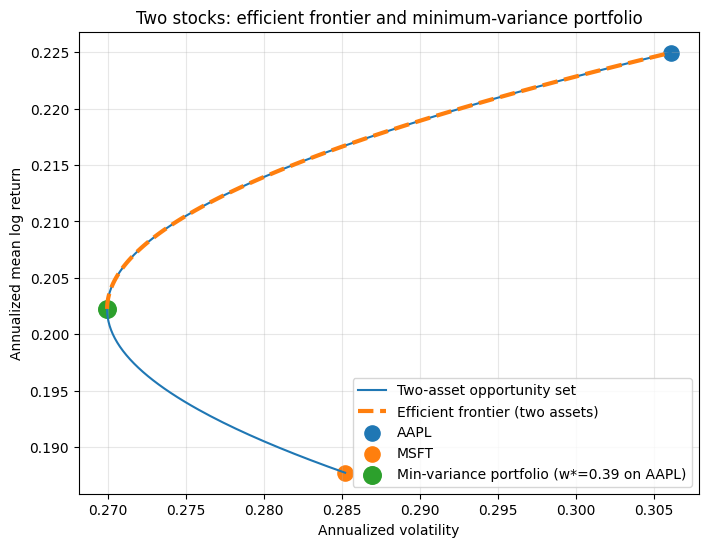

Minimum-variance weight on AAPL: w* = 0.3895
Minimum-variance portfolio: mean log return = 0.2022, volatility = 0.2699


In [ ]:
# Closed-form minimum-variance weight for a 2-asset portfolio
sig1_sq = cov2_ann.loc[stock1, stock1]
sig2_sq = cov2_ann.loc[stock2, stock2]
denominator = sig1_sq + sig2_sq - 2 * cov12_ann

if abs(denominator) < 1e-12:
    raise ValueError("Cannot compute minimum-variance weight: denominator is too close to zero.")

# Unconstrained solution
w_star_unconstrained = (sig2_sq - cov12_ann) / denominator

# For this notebook section we stay long-only, so we clip to [0, 1]
w_star = float(np.clip(w_star_unconstrained, 0.0, 1.0))
mu_star, sig_star = portfolio_mu_sigma_two(w_star, mu2, cov2_ann)

# Efficient branch (long-only): points with return >= return at min-variance point
mask_eff = mus >= (mu_star - 1e-12)

plt.figure(figsize=(8, 6))
plt.plot(sigs, mus, label="Two-asset opportunity set")
plt.plot(sigs[mask_eff], mus[mask_eff], linewidth=3, linestyle="--", label="Efficient frontier (two assets)")
plt.scatter(sig2[stock1], mu2[stock1], s=120, label=stock1)
plt.scatter(sig2[stock2], mu2[stock2], s=120, label=stock2)
plt.scatter(sig_star, mu_star, s=160, label=f"Min-variance portfolio (w*={w_star:.2f} on {stock1})")
plt.xlabel("Annualized volatility")
plt.ylabel("Annualized mean log return")
plt.title("Two stocks: efficient frontier and minimum-variance portfolio")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

if not np.isclose(w_star, w_star_unconstrained):
    print("Note: unconstrained min-variance weight was outside [0,1], so it was clipped for long-only analysis.")

print(f"Minimum-variance weight on {stock1}: w* = {w_star:.4f}")
print(f"Minimum-variance portfolio: mean log return = {mu_star:.4f}, volatility = {sig_star:.4f}")

## 4) Three Stocks: From Pairwise Frontiers to a Simplex

With three risky assets, long-only weights satisfy
$$
w_1+w_2+w_3=1,
\qquad
w_i\ge 0,
$$
so admissible portfolios lie on a 2-simplex (a triangle in weight space).

The next code cell makes this geometry explicit:
1. adds `GOOGL` and builds `mu3`, `cov3`,
2. draws the three pairwise curves (`AAPL`-`MSFT`, `AAPL`-`GOOGL`, `MSFT`-`GOOGL`),
3. samples the full simplex on a weight grid with `step=0.02`, and
4. shows both the barycentric simplex view and the corresponding mean-volatility cloud.

Analytical notes connected to the code:
- Pairwise curves are simplex edges (one weight fixed at zero).
- Interior simplex points have all three weights positive and can deliver portfolios unavailable on any edge.
- With `step=0.02`, the number of sampled weight triples is
$$
\binom{50+2}{2}=1326,
$$
which is exactly what the code constructs.

This section is the key bridge from low-dimensional geometry to high-dimensional portfolio sets.

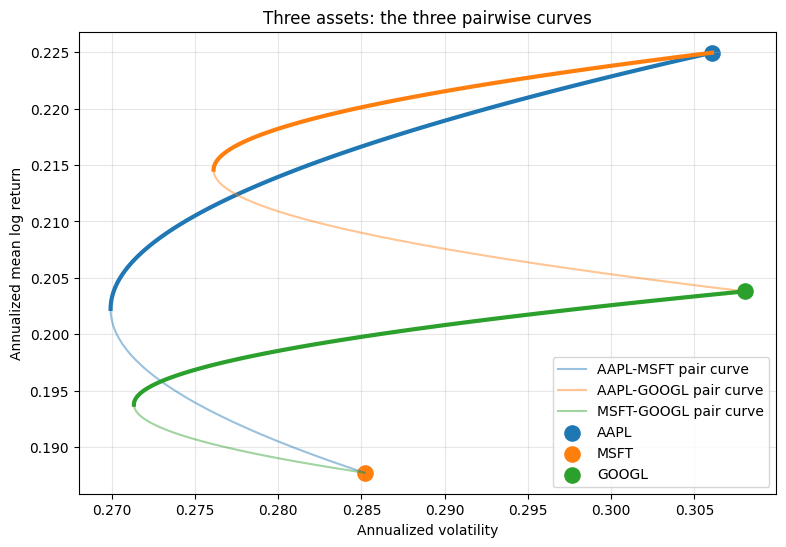

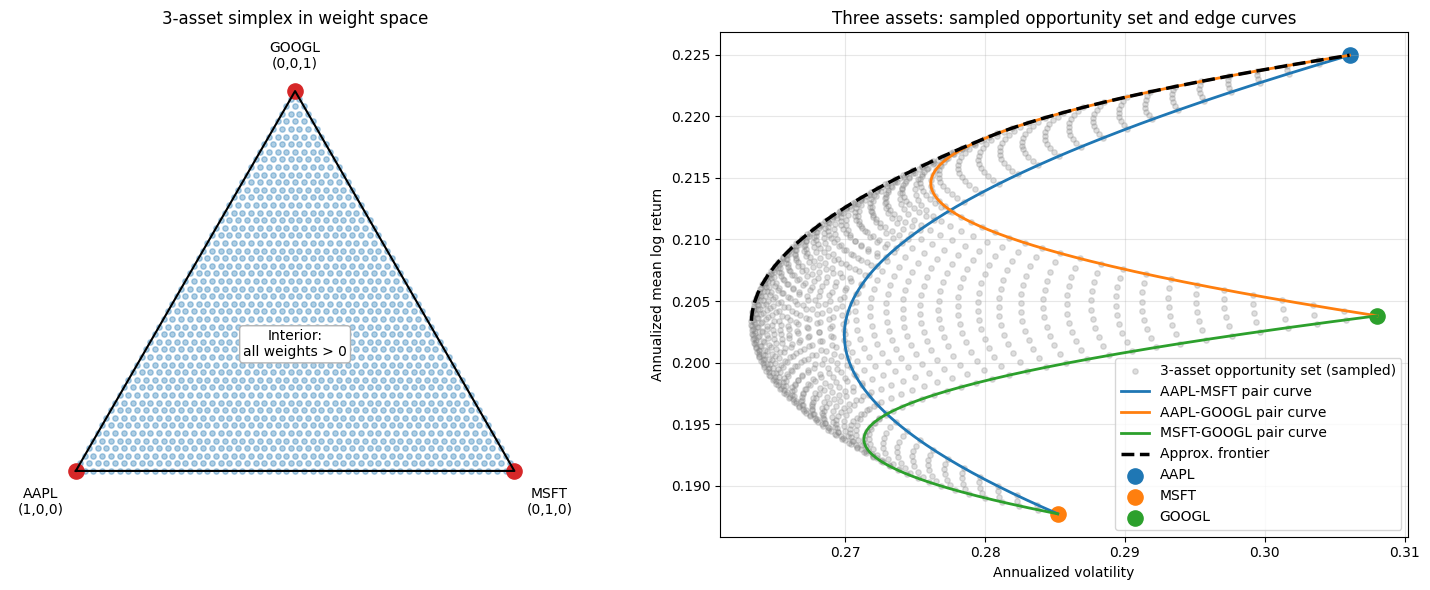

Number of sampled 3-asset portfolios: 1326


In [ ]:

stock3 = "GOOGL"

assets3 = [stock1, stock2, stock3]
mu3 = mu_ann[assets3]
cov3 = returns_daily[assets3].cov() * 252

def portfolio_mu_sigma(weights, mu_vec, cov_mat):
    """Portfolio mean return and volatility for a generic weight vector."""
    weights = np.asarray(weights, dtype=float)
    mu_p = float(weights @ mu_vec.values)
    var_p = float(weights @ cov_mat.values @ weights)
    sig_p = np.sqrt(max(var_p, 0.0))
    return mu_p, sig_p

def upper_envelope(points):
    """
    Approximate the efficient frontier from a cloud of (risk, return) points.
    We keep points that improve return as risk increases.
    """
    points = np.asarray(points, dtype=float)
    points = points[np.isfinite(points).all(axis=1)]
    points = np.unique(points, axis=0)

    if len(points) == 0:
        return np.empty((0, 2))

    # ConvexHull gives a cleaner boundary when the cloud is dense.
    if len(points) >= 3:
        try:
            hull = ConvexHull(points)
            candidates = points[hull.vertices]
        except Exception:
            candidates = points
    else:
        candidates = points

    candidates = candidates[np.argsort(candidates[:, 0])]

    efficient = []
    best_return_so_far = -np.inf
    for risk, ret in candidates:
        if ret > best_return_so_far + 1e-12:
            efficient.append((risk, ret))
            best_return_so_far = ret

    return np.array(efficient)

# 1) Draw the three pairwise 2-asset curves (edges of the 3-asset simplex)
pair_specs = [(stock1, stock2), (stock1, stock3), (stock2, stock3)]
pair_curves = {}
pair_colors = ["tab:blue", "tab:orange", "tab:green"]

plt.figure(figsize=(9, 6))
for color, (a, b) in zip(pair_colors, pair_specs):
    mu_pair = mu_ann[[a, b]]
    cov_pair = returns_daily[[a, b]].cov() * 252

    pair_mus = []
    pair_sigs = []
    for w in W:
        mu_p, sig_p = portfolio_mu_sigma_two(w, mu_pair, cov_pair)
        pair_mus.append(mu_p)
        pair_sigs.append(sig_p)

    pair_mus = np.array(pair_mus)
    pair_sigs = np.array(pair_sigs)

    min_idx = np.argmin(pair_sigs)
    eff_mask = pair_mus >= (pair_mus[min_idx] - 1e-12)

    pair_curves[(a, b)] = {
        "mus": pair_mus,
        "sigs": pair_sigs,
        "eff_mask": eff_mask,
        "color": color,
    }

    plt.plot(pair_sigs, pair_mus, color=color, alpha=0.45, label=f"{a}-{b} pair curve")
    plt.plot(pair_sigs[eff_mask], pair_mus[eff_mask], color=color, linewidth=3)

for a in assets3:
    plt.scatter(sigma_ann[a], mu_ann[a], s=120, label=a)

plt.xlabel("Annualized volatility")
plt.ylabel("Annualized mean log return")
plt.title("Three assets: the three pairwise curves")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 2) Sample the full 3-asset simplex with a grid of weights
step = 0.02
w_points = []
for w1 in np.arange(0, 1 + 1e-12, step):
    for w2 in np.arange(0, 1 - w1 + 1e-12, step):
        w3 = 1 - w1 - w2
        w_points.append([w1, w2, w3])
w_points = np.array(w_points)

mus3 = []
sigs3 = []
for w_vec in w_points:
    mu_p, sig_p = portfolio_mu_sigma(w_vec, mu3, cov3)
    mus3.append(mu_p)
    sigs3.append(sig_p)

mus3 = np.array(mus3)
sigs3 = np.array(sigs3)
frontier3_num = upper_envelope(np.column_stack((sigs3, mus3)))

# 3) Barycentric picture (weight simplex) + mean-volatility picture
simplex_vertices = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [0.5, np.sqrt(3) / 2],
])

simplex_coords = w_points @ simplex_vertices
simplex_outline = np.vstack([simplex_vertices, simplex_vertices[0]])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax0, ax1 = axes

ax0.plot(simplex_outline[:, 0], simplex_outline[:, 1], color="black", linewidth=1.5)
ax0.scatter(simplex_coords[:, 0], simplex_coords[:, 1], alpha=0.35, s=15, color="tab:blue")

vertex_labels = [
    f"{stock1}\n(1,0,0)",
    f"{stock2}\n(0,1,0)",
    f"{stock3}\n(0,0,1)",
]
offsets = np.array([[-0.08, -0.07], [0.08, -0.07], [0.00, 0.08]])
for (x, y), label, (dx, dy) in zip(simplex_vertices, vertex_labels, offsets):
    ax0.scatter(x, y, s=120, color="tab:red")
    ax0.text(x + dx, y + dy, label, ha="center", va="center")

barycenter = np.array([1 / 3, 1 / 3, 1 / 3]) @ simplex_vertices
ax0.text(
    barycenter[0],
    barycenter[1],
    "Interior:\nall weights > 0",
    ha="center",
    va="center",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7"),
)
ax0.set_title("3-asset simplex in weight space")
ax0.set_aspect("equal")
ax0.set_xlim(-0.15, 1.15)
ax0.set_ylim(-0.15, 1.0)
ax0.axis("off")

ax1.scatter(sigs3, mus3, alpha=0.25, s=15, color="tab:gray", label="3-asset opportunity set (sampled)")
for (a, b), curve in pair_curves.items():
    ax1.plot(curve["sigs"], curve["mus"], color=curve["color"], linewidth=2, label=f"{a}-{b} pair curve")

if frontier3_num.size > 0:
    ax1.plot(frontier3_num[:, 0], frontier3_num[:, 1], color="black", linewidth=2.5, linestyle="--", label="Approx. frontier")

for a in assets3:
    ax1.scatter(sigma_ann[a], mu_ann[a], s=120, label=a)

ax1.set_xlabel("Annualized volatility")
ax1.set_ylabel("Annualized mean log return")
ax1.set_title("Three assets: sampled opportunity set and edge curves")
ax1.grid(alpha=0.3)
ax1.legend()
plt.tight_layout()
plt.show()

print(f"Number of sampled 3-asset portfolios: {len(w_points)}")

## 5) Many Stocks (30): A Numerical Opportunity Set First

With 30 assets, plotting every feasible portfolio exactly is impossible, so the next code cell compares two sampling designs on the same inputs (`mean_returns`, `cov_matrix`):

1. `simplex_grid(d, m)` with `d=30`, `m=5`.
- Weights are multiples of $1/5$ and sum to 1.
- Number of portfolios is combinatorial:
$$
\#\text{grid points}=\binom{m+d-1}{m}=\binom{34}{5}=278{,}256.
$$

2. Dirichlet sampling with `alpha=1.0` and the same number of points.
- Draws random long-only weights over the simplex.

For each cloud, the code computes $(\mu_p,\sigma_p)$ and overlays an approximate upper envelope (`upper_envelope`) as a numerical frontier proxy.

Finance intuition: the sampling design affects which parts of the feasible set are visible; if sampling misses certain regions, the observed "frontier" can look artificially conservative.

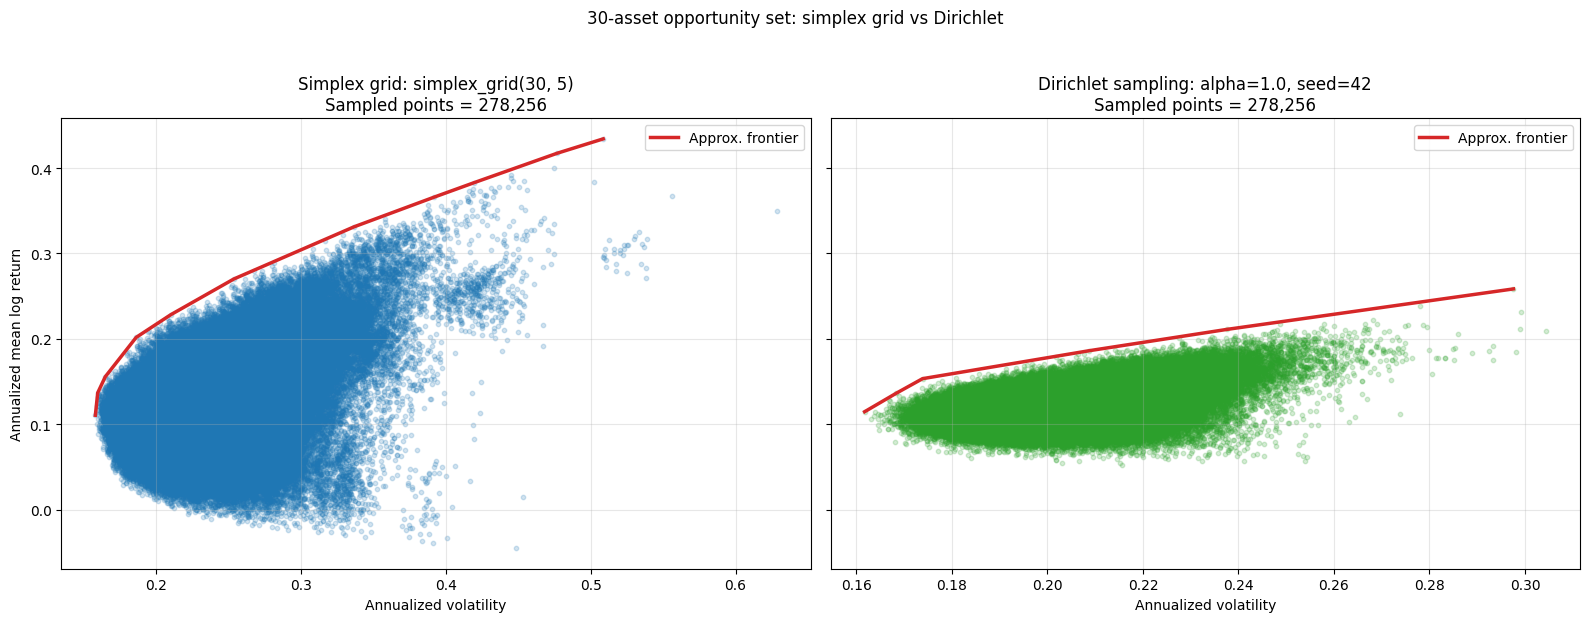

Number of portfolios from simplex_grid(30, 5): 278256
Number of portfolios from Dirichlet sampling: 278256


In [ ]:
# Use already-computed annualized means/covariances from daily log returns
mean_returns = mu_ann
cov_matrix = returns_daily.cov() * 252

def simplex_grid(num_assets, m):
    """
    Exhaustive long-only grid.
    Each weight is a multiple of 1/m and all weights sum to 1.
    """
    partitions = itertools.combinations_with_replacement(range(num_assets), m)
    grid = []

    for partition in partitions:
        w = np.zeros(num_assets)
        for idx in partition:
            w[idx] += 1
        grid.append(w / m)

    return np.array(grid)

def dirichlet_sample(num_assets, num_samples, alpha=1.0, seed=None):
    """Random long-only weights sampled from a Dirichlet distribution."""
    rng = np.random.default_rng(seed)
    alpha_vec = np.full(num_assets, alpha) if np.isscalar(alpha) else np.asarray(alpha)
    return rng.dirichlet(alpha_vec, size=num_samples)

def portfolio_cloud(weight_points, mean_returns, cov_matrix):
    """Vectorized portfolio mean/volatility for many weight vectors."""
    means = weight_points @ mean_returns.values
    variances = np.einsum("ij,jk,ik->i", weight_points, cov_matrix.values, weight_points)
    stds = np.sqrt(np.clip(variances, 0.0, None))
    return means, stds

d = len(TICKERS)
m = 5  # Weights are multiples of 1/5; increase m for finer (but heavier) grids.

# Method 1: exhaustive simplex grid
grid_points = simplex_grid(d, m)
num_grid = len(grid_points)

# Method 2: random Dirichlet sampling (same number of points for fair comparison)
dirichlet_points = dirichlet_sample(d, num_samples=num_grid, alpha=1.0, seed=42)
num_dirichlet = len(dirichlet_points)

# Portfolio means/volatilities for both methods
grid_means, grid_stds = portfolio_cloud(grid_points, mean_returns, cov_matrix)
dir_means, dir_stds = portfolio_cloud(dirichlet_points, mean_returns, cov_matrix)

# Approximate frontiers (upper envelope of each cloud)
grid_frontier = upper_envelope(np.column_stack((grid_stds, grid_means)))
dir_frontier = upper_envelope(np.column_stack((dir_stds, dir_means)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

ax0 = axes[0]
ax0.scatter(grid_stds, grid_means, alpha=0.20, s=10, color="tab:blue")
if grid_frontier.size > 0:
    ax0.plot(grid_frontier[:, 0], grid_frontier[:, 1], color="tab:red", linewidth=2.5, label="Approx. frontier")
ax0.set_title(f"Simplex grid: simplex_grid({d}, {m})\nSampled points = {num_grid:,}")
ax0.set_xlabel("Annualized volatility")
ax0.set_ylabel("Annualized mean log return")
ax0.grid(True, alpha=0.3)
ax0.legend()

ax1 = axes[1]
ax1.scatter(dir_stds, dir_means, alpha=0.20, s=10, color="tab:green")
if dir_frontier.size > 0:
    ax1.plot(dir_frontier[:, 0], dir_frontier[:, 1], color="tab:red", linewidth=2.5, label="Approx. frontier")
ax1.set_title(f"Dirichlet sampling: alpha=1.0, seed=42\nSampled points = {num_dirichlet:,}")
ax1.set_xlabel("Annualized volatility")
ax1.grid(True, alpha=0.3)
ax1.legend()

fig.suptitle("30-asset opportunity set: simplex grid vs Dirichlet", y=1.03)
plt.tight_layout()
plt.show()

print(f"Number of portfolios from simplex_grid({d}, {m}): {num_grid}")
print(f"Number of portfolios from Dirichlet sampling: {num_dirichlet}")

## 6) Many Stocks: Efficient Frontier via Optimization

Sampling is exploratory. The optimization frontier is the benchmark.
The next code cell solves the long-only Markowitz problem on annualized log-return moments.

For a target return $\mu^*$, the optimization is:
$$
\min_w \; w^\top\Sigma w
\quad\text{s.t.}\quad
\mathbf{1}^\top w=1,
\; \mu^\top w=\mu^*,
\; w_i\ge 0.
$$
(The code minimizes volatility directly; this is equivalent because $\sqrt{\cdot}$ is monotone.)

### Analytical benchmark: global minimum-variance portfolio for $n$ risky assets

Before imposing the long-only bounds used in code, the fully invested global minimum-variance (GMV) problem is:
$$
\min_w \; w^\top\Sigma w
\quad\text{s.t.}\quad
\mathbf{1}^\top w = 1.
$$
Assume $\Sigma$ is invertible (positive definite). Use the Lagrangian
$$
\mathcal{L}(w,\lambda)=w^\top\Sigma w-\lambda(\mathbf{1}^\top w-1).
$$
First-order condition with respect to $w$:
$$
\nabla_w\mathcal{L}=2\Sigma w-\lambda\mathbf{1}=0
\quad\Longrightarrow\quad
w=\frac{\lambda}{2}\Sigma^{-1}\mathbf{1}.
$$
Impose the budget constraint $\mathbf{1}^\top w=1$:
$$
1=\mathbf{1}^\top\left(\frac{\lambda}{2}\Sigma^{-1}\mathbf{1}\right)
=\frac{\lambda}{2}\,\mathbf{1}^\top\Sigma^{-1}\mathbf{1}
\quad\Longrightarrow\quad
\lambda=\frac{2}{\mathbf{1}^\top\Sigma^{-1}\mathbf{1}}.
$$
Substitute back:
$$
w_{MV}=\frac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}^\top\Sigma^{-1}\mathbf{1}}.
$$
The minimum achievable variance is
$$
\operatorname{Var}(r_{MV})=w_{MV}^\top\Sigma w_{MV}
=\frac{1}{\mathbf{1}^\top\Sigma^{-1}\mathbf{1}}.
$$

Finance intuition: $\Sigma^{-1}\mathbf{1}$ tilts weights toward assets that contribute less covariance risk to the whole portfolio, and the denominator simply rescales to make weights sum to one.

Connection to the notebook code:
- `min_variance_weights(cov_matrix)` solves the *long-only* version numerically with SLSQP (`w_i\in[0,1]`).
- The closed form above is the unconstrained fully invested benchmark.
- If the closed-form weights are already long-only, the numerical solution coincides with the formula; if some weights are negative, long-only constraints bind and the code returns a constrained GMV portfolio with weakly higher variance.

The cell then performs:
1. minimum-variance optimization (`min_variance_weights`),
2. a sweep over target returns from the minimum-variance return up to `mean_returns.max()`,
3. constrained optimization for each target (`efficient_frontier_vol`), and
4. plotting of feasible frontier points plus the minimum-variance portfolio.

Interpretation: this frontier is the economically relevant long-only efficient set for the 30 risky assets under the notebook's return convention.

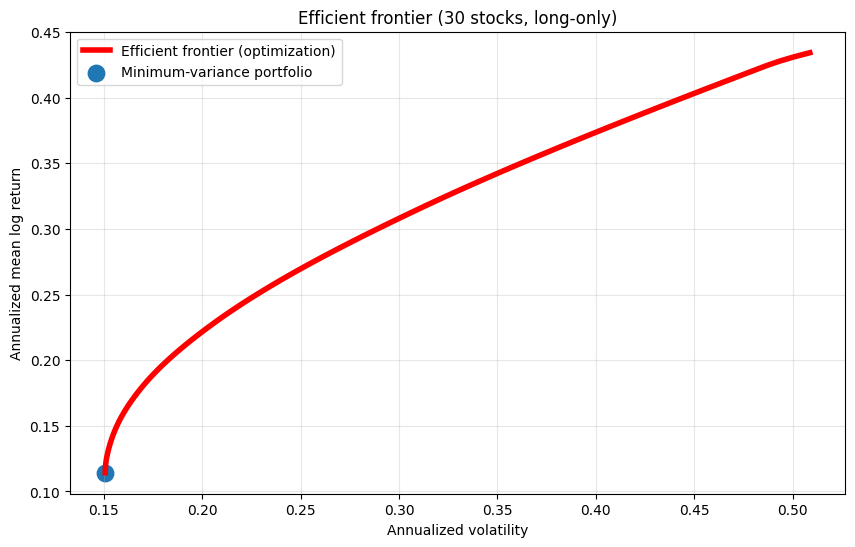

Minimum-variance portfolio: mean log return = 0.1143, volatility = 0.1509


In [ ]:
def portfolio_volatility(weights, cov_matrix):
    """Portfolio standard deviation given weights and covariance matrix."""
    weights = np.asarray(weights, dtype=float)
    cov_values = cov_matrix.values if hasattr(cov_matrix, "values") else np.asarray(cov_matrix, dtype=float)
    variance = float(weights.T @ cov_values @ weights)
    return np.sqrt(max(variance, 0.0))

def min_variance_weights(cov_matrix):
    """Long-only minimum-variance portfolio (weights sum to 1)."""
    num_assets = cov_matrix.shape[0]
    w0 = np.ones(num_assets) / num_assets
    bounds = [(0, 1) for _ in range(num_assets)]
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]

    res = minimize(
        portfolio_volatility,
        w0,
        args=(cov_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
    )

    if not res.success:
        raise RuntimeError(f"Minimum-variance optimization failed: {res.message}")

    return res.x

def efficient_frontier_vol(target_return, mean_returns, cov_matrix):
    """Minimum volatility for a given target return (long-only, fully invested)."""
    num_assets = len(mean_returns)
    w0 = np.ones(num_assets) / num_assets
    bounds = [(0, 1) for _ in range(num_assets)]
    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        {"type": "eq", "fun": lambda w: float(w @ mean_returns.values) - float(target_return)},
    ]

    res = minimize(
        portfolio_volatility,
        w0,
        args=(cov_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
    )

    return float(res.fun) if res.success else np.nan

# Compute minimum-variance portfolio (30 assets)
w_minvar = min_variance_weights(cov_matrix)
minvar_return = float(w_minvar @ mean_returns.values)
minvar_risk = portfolio_volatility(w_minvar, cov_matrix)

# Sweep target returns from min-variance return up to the highest individual mean
target_returns = np.linspace(minvar_return, float(mean_returns.max()), 100)
efficient_risks = np.array([efficient_frontier_vol(r, mean_returns, cov_matrix) for r in target_returns])

# Keep only feasible optimization results
mask = np.isfinite(efficient_risks)
if not mask.any():
    raise RuntimeError("No feasible efficient-frontier points were found.")

efficient_risks_clean = efficient_risks[mask]
target_returns_clean = target_returns[mask]

plt.figure(figsize=(10, 6))
plt.plot(efficient_risks_clean, target_returns_clean, color="red", linewidth=4, label="Efficient frontier (optimization)")
plt.scatter(minvar_risk, minvar_return, s=140, label="Minimum-variance portfolio")
plt.xlabel("Annualized volatility")
plt.ylabel("Annualized mean log return")
plt.title("Efficient frontier (30 stocks, long-only)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Minimum-variance portfolio: mean log return = {minvar_return:.4f}, volatility = {minvar_risk:.4f}")

## 7) How Good Is the Numerical Frontier?

The next code cell compares sampled frontiers against the optimization benchmark in three panels:
- 3 assets (dense simplex sampling),
- 30 assets with `simplex_grid`,
- 30 assets with Dirichlet sampling.

Each panel overlays:
1. sampled portfolio cloud,
2. numerical frontier proxy from `upper_envelope`,
3. optimization-based frontier.

Why this matters pedagogically: it separates two ideas that are often conflated.
- A sampled frontier is a data-density artifact.
- The optimization frontier is a constrained optimum.

The visual gap between the two is the approximation error induced by the chosen sampling method.

/tmp/ipykernel_796/1778145970.py:74: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


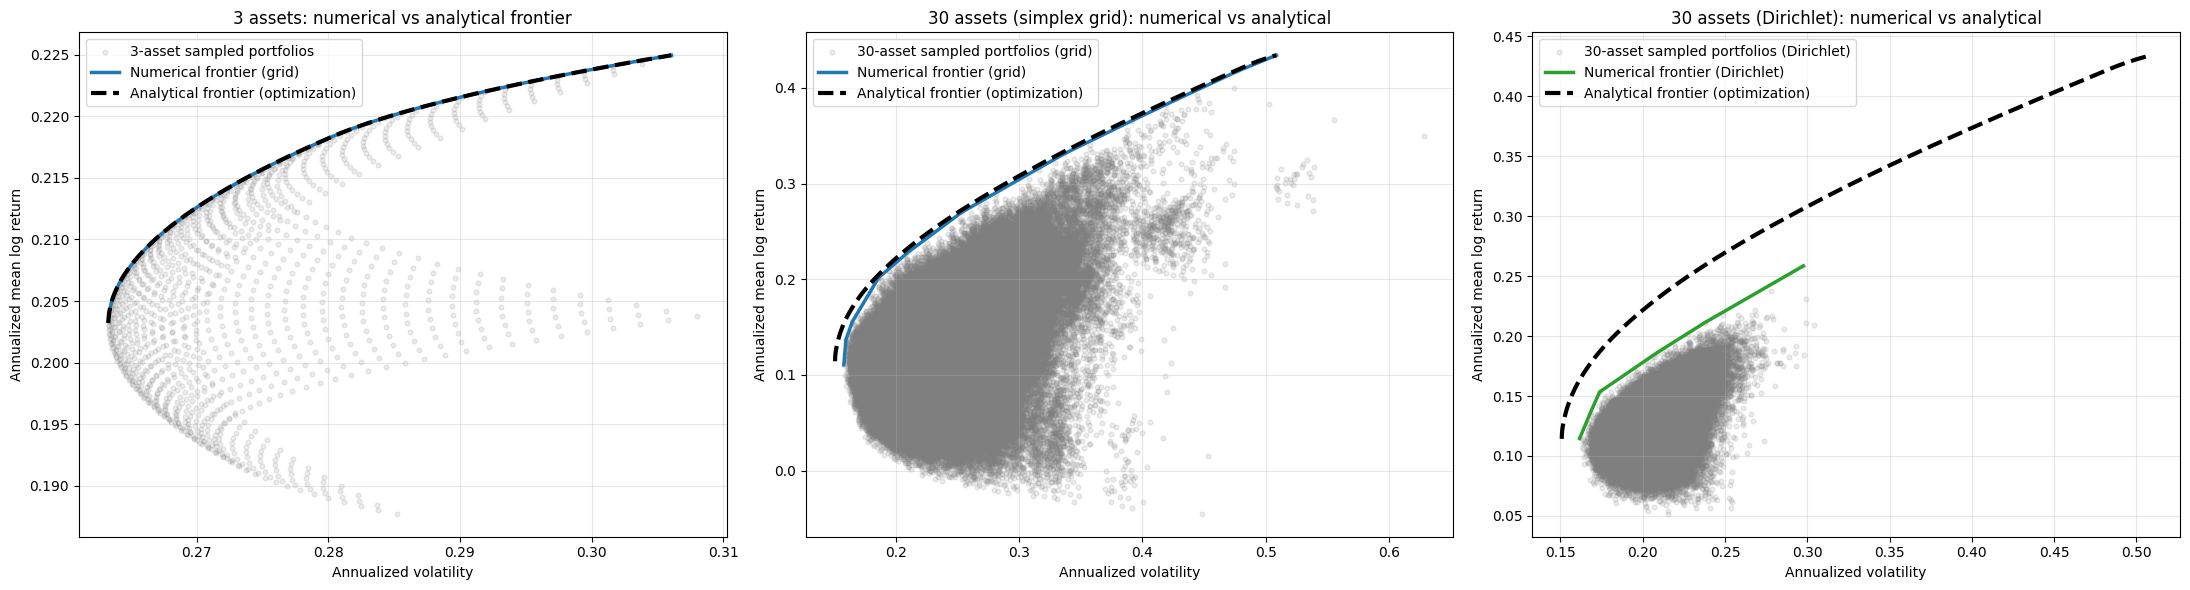

In [ ]:
# Compare numerical frontiers (sampled clouds) with optimization-based frontiers
required_vars = [
    "mu3", "cov3", "sigs3", "mus3", "frontier3_num",
    "grid_stds", "grid_means", "grid_frontier",
    "dir_stds", "dir_means", "dir_frontier",
    "efficient_risks_clean", "target_returns_clean"
]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError("Missing variables: " + ", ".join(missing) + ". Run previous sections first.")

# 3-asset analytical frontier from constrained optimization
mean_returns3 = mu3
cov_matrix3 = cov3

w3_minvar = min_variance_weights(cov_matrix3)
minvar_return3 = float(w3_minvar @ mean_returns3.values)

target_returns3 = np.linspace(minvar_return3, float(mean_returns3.max()), 140)
efficient_risks3 = np.array([efficient_frontier_vol(r, mean_returns3, cov_matrix3) for r in target_returns3])

mask3 = np.isfinite(efficient_risks3)
if not mask3.any():
    raise RuntimeError("No feasible 3-asset efficient-frontier points were found.")

analytical3 = np.column_stack((efficient_risks3[mask3], target_returns3[mask3]))
analytical3 = analytical3[np.argsort(analytical3[:, 0])]
analytical3 = upper_envelope(analytical3)

# 30-asset analytical frontier (already computed in Section 6)
analytical30 = np.column_stack((efficient_risks_clean, target_returns_clean))
analytical30 = analytical30[np.argsort(analytical30[:, 0])]
analytical30 = upper_envelope(analytical30)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
ax0, ax1, ax2 = axes

# Left: 3 assets
ax0.scatter(sigs3, mus3, alpha=0.15, s=12, color="tab:gray", label="3-asset sampled portfolios")
if frontier3_num.size > 0:
    ax0.plot(frontier3_num[:, 0], frontier3_num[:, 1], color="tab:blue", linewidth=2.5, label="Numerical frontier (grid)")
if analytical3.size > 0:
    ax0.plot(analytical3[:, 0], analytical3[:, 1], color="black", linewidth=3, linestyle="--", label="Analytical frontier (optimization)")
ax0.set_title("3 assets: numerical vs analytical frontier")
ax0.set_xlabel("Annualized volatility")
ax0.set_ylabel("Annualized mean log return")
ax0.grid(True, alpha=0.3)
ax0.legend()

# Middle: 30 assets, simplex grid cloud
ax1.scatter(grid_stds, grid_means, alpha=0.15, s=12, color="tab:gray", label="30-asset sampled portfolios (grid)")
if grid_frontier.size > 0:
    ax1.plot(grid_frontier[:, 0], grid_frontier[:, 1], color="tab:blue", linewidth=2.5, label="Numerical frontier (grid)")
if analytical30.size > 0:
    ax1.plot(analytical30[:, 0], analytical30[:, 1], color="black", linewidth=3, linestyle="--", label="Analytical frontier (optimization)")
ax1.set_title("30 assets (simplex grid): numerical vs analytical")
ax1.set_xlabel("Annualized volatility")
ax1.set_ylabel("Annualized mean log return")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Right: 30 assets, Dirichlet cloud
ax2.scatter(dir_stds, dir_means, alpha=0.15, s=12, color="tab:gray", label="30-asset sampled portfolios (Dirichlet)")
if dir_frontier.size > 0:
    ax2.plot(dir_frontier[:, 0], dir_frontier[:, 1], color="tab:green", linewidth=2.5, label="Numerical frontier (Dirichlet)")
if analytical30.size > 0:
    ax2.plot(analytical30[:, 0], analytical30[:, 1], color="black", linewidth=3, linestyle="--", label="Analytical frontier (optimization)")
ax2.set_title("30 assets (Dirichlet): numerical vs analytical")
ax2.set_xlabel("Annualized volatility")
ax2.set_ylabel("Annualized mean log return")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## 8) Diversification and Risk: 1 Stock, 2 Stocks, ..., $30$ Stocks

Before adding a risk-free asset, it is useful to isolate pure diversification among risky assets.
This section quantifies how total volatility changes with portfolio breadth under equal weights.

The next code cell runs the following experiment:
1. randomly permute the 30 stocks,
2. for each permutation, build equal-weight portfolios of size $n=1,\dots,30$,
3. compute each portfolio's annualized volatility,
4. repeat over many permutations (`num_simulations=100`),
5. average volatility at each portfolio size.

Implementation detail aligned with earlier sections:
- The one-period equal-weight return is first computed in simple-return form.
- It is then converted to log return via `np.log1p(...)` before annualized volatility is measured.

### Analytical derivation: equal weights and the limit as $n\to\infty$

Start from equal weights $w_i=1/n$. The one-period portfolio return is
$$
r_p=\sum_{i=1}^n \frac{1}{n}r_i.
$$
Therefore
$$
\operatorname{Var}(r_p)
=\operatorname{Var}\!\left(\sum_{i=1}^n\frac{1}{n}r_i\right)
=\frac{1}{n^2}\sum_{i=1}^n\sum_{j=1}^n\operatorname{Cov}(r_i,r_j).
$$
Decompose diagonal and off-diagonal terms:
$$
\operatorname{Var}(r_p)
=\frac{1}{n^2}\left(\sum_{i=1}^n\operatorname{Var}(r_i)
+\sum_{i\ne j}\operatorname{Cov}(r_i,r_j)\right).
$$
Define
$$
\bar v_n=\frac{1}{n}\sum_{i=1}^n\operatorname{Var}(r_i),
\qquad
\bar c_n=\frac{1}{n(n-1)}\sum_{i\ne j}\operatorname{Cov}(r_i,r_j).
$$
Then
$$
\operatorname{Var}(r_p)=\frac{\bar v_n}{n}+\frac{n-1}{n}\bar c_n.
$$
If $\bar v_n$ stays bounded and $\bar c_n\to \bar c$ as $n$ grows, then
$$
\frac{\bar v_n}{n}\to 0,
\qquad
\frac{n-1}{n}\bar c_n\to \bar c,
$$
so
$$
\operatorname{Var}(r_p)\to \bar c.
$$
This is the precise diversification result: idiosyncratic variance averages out, while average co-movement remains.

Connection to the code in this notebook:
- The code computes a cross-sectional average of off-diagonal entries of the annualized covariance matrix and plots `sqrt(avg covariance)` as a floor proxy.
- This matches the limiting logic above: with many assets, portfolio variance is dominated by average covariance, not by average standalone variance.
- Because the code reports volatility from log returns (`log1p` of simple equal-weight return), the formula is interpreted as the same diversification mechanism in the simple-return space that underlies those computations.

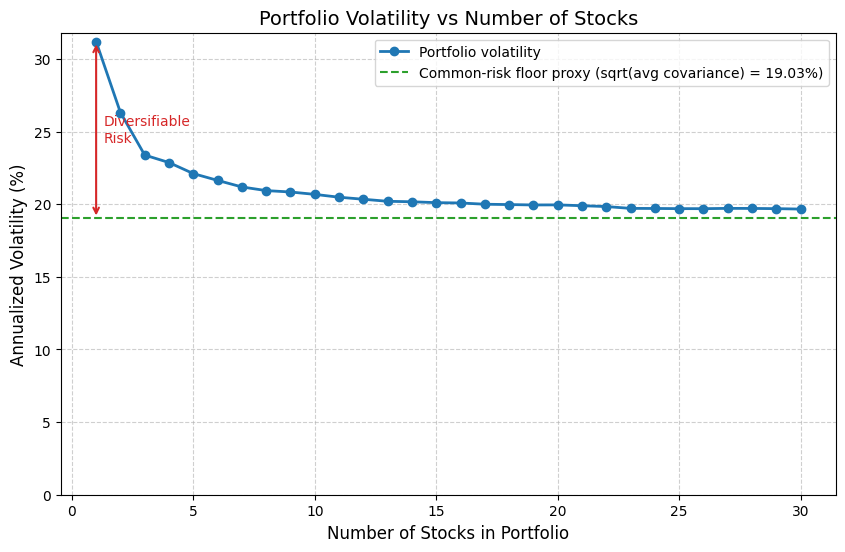

In [ ]:
 #Beginner guide:
# - Purpose: show diversification by tracking volatility as portfolio size grows (1 to N stocks).
# - For each random stock order, we form equal-weight portfolios incrementally.
# - We compute portfolio volatility from daily log returns and annualize with sqrt(252).
# - `avg_std_devs` is the average volatility path across many random simulations.
# - The dashed line approximates the common-risk floor from average off-diagonal covariance.
# Diversification experiment: how risk changes when we add more stocks
# Procedure:
# 1) Randomly reorder stocks many times.
# 2) For each random order, build equal-weight portfolios with 1,2,...,N stocks.
# 3) Compute annualized volatility for each portfolio size.
# 4) Average across simulations.

rng = np.random.default_rng(42)
num_simulations = 100
num_stocks = len(returns_daily.columns)

# Store annualized volatilities (%) by portfolio size n = 1,...,N
portfolio_std_devs = {n: [] for n in range(1, num_stocks + 1)}

for _ in range(num_simulations):
    # Random permutation of stock tickers (without replacement)
    ordered_stocks = rng.permutation(returns_daily.columns)

    current_portfolio = []
    for i, stock in enumerate(ordered_stocks):
        current_portfolio.append(stock)

        # Equal-weight daily simple return across currently selected stocks
        portfolio_simple_returns = simple_returns_daily[current_portfolio].mean(axis=1)

        # Convert to daily log returns for consistency with notebook conventions
        portfolio_log_returns = np.log1p(portfolio_simple_returns)

        # Annualized volatility = std(daily returns) * sqrt(252)
        annualized_std = portfolio_log_returns.std() * np.sqrt(252)

        portfolio_std_devs[i + 1].append(annualized_std * 100)

# Average volatility for each portfolio size
avg_std_devs = [np.mean(portfolio_std_devs[n]) for n in range(1, num_stocks + 1)]

# Common-risk floor proxy:
# sqrt(average off-diagonal covariance), using annualized covariance matrix
cov_matrix_ann = returns_daily.cov() * 252
off_diag_cov = cov_matrix_ann.values[np.triu_indices_from(cov_matrix_ann, k=1)]
avg_cov_ann = off_diag_cov.mean()
common_risk_floor_pct = np.sqrt(max(avg_cov_ann, 0.0)) * 100

plt.figure(figsize=(10, 6))

# Risk vs number of stocks
plt.plot(
    range(1, num_stocks + 1),
    avg_std_devs,
    marker="o",
    linestyle="-",
    color="tab:blue",
    linewidth=2,
    label="Portfolio volatility",
)

# Horizontal line for common-risk floor proxy
plt.axhline(
    common_risk_floor_pct,
    color="tab:green",
    linestyle="--",
    linewidth=1.5,
    label=f"Common-risk floor proxy (sqrt(avg covariance) = {common_risk_floor_pct:.2f}%)",
)

# Arrow showing diversifiable risk at n=1
one_stock_std_dev = avg_std_devs[0]
plt.annotate(
    "",
    xy=(1, common_risk_floor_pct),
    xytext=(1, one_stock_std_dev),
    arrowprops=dict(arrowstyle="<->", color="tab:red", linewidth=1.5),
)
plt.text(
    1.3,
    (one_stock_std_dev + common_risk_floor_pct) / 2,
    "Diversifiable\nRisk",
    color="tab:red",
    fontsize=10,
    va="center",
    ha="left",
)

plt.ylim(0)
plt.title("Portfolio Volatility vs Number of Stocks", fontsize=14)
plt.xlabel("Number of Stocks in Portfolio", fontsize=12)
plt.ylabel("Annualized Volatility (%)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.show()

## 9) Adding a Risk-Free Asset: Capital Market Line and the Sharpe Ratio

After studying pure diversification across risky assets, this section adds a risk-free asset to the risky-asset frontier.
The code starts from a simple annual rate `rf_simple = 0.02` and converts it to the log-return scale used above:
$$
r_f = \log(1+r_f^{\text{simple}}).
$$

Then it solves for the long-only tangency portfolio by maximizing Sharpe ratio:
$$
\max_w \frac{w^\top\mu-r_f}{\sqrt{w^\top\Sigma w}}
\quad\text{s.t.}\quad
\mathbf{1}^\top w=1,\; w_i\in[0,1].
$$
(Implemented by minimizing `negative_sharpe` with SLSQP.)

If $(\mu_T,\sigma_T)$ is the tangency portfolio, combinations with the risk-free asset satisfy
$$
\mu_C(\lambda)=r_f+\lambda(\mu_T-r_f),
\qquad
\sigma_C(\lambda)=\lambda\sigma_T,
$$
which is exactly the line plotted in code (with `\lambda` up to 1.5, allowing leverage).

Finance intuition: the CML slope equals the tangency Sharpe ratio, so tangency is the best risky portfolio per unit of volatility when a risk-free asset is available.

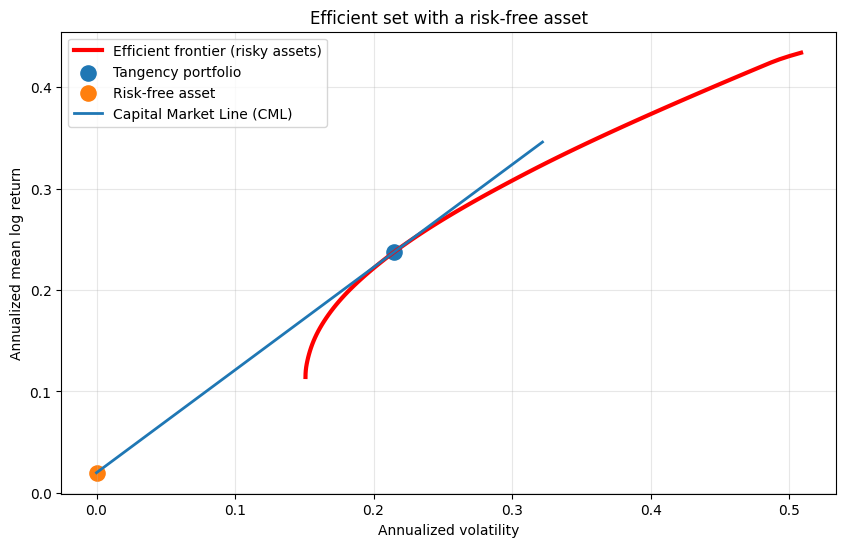

Assumed risk-free rate: simple annual = 2.00%, continuous annual = 0.0198
Tangency portfolio: mean log return = 0.2373, volatility = 0.2146, Sharpe = 1.013


In [ ]:
# Beginner guide:
# - Purpose: add a risk-free asset and find the tangency (maximum Sharpe) risky portfolio.
# - `rf_simple` is converted to log-return scale (`rf`) to match the notebook convention.
# - `negative_sharpe(...)` is minimized so that Sharpe ratio is maximized.
# - Optimization enforces long-only weights summing to 1.
# - The Capital Market Line (CML) is drawn by mixing the risk-free asset with the tangency portfolio.
# Add a risk-free asset and compute the tangency portfolio (max Sharpe ratio)
rf_simple = 0.02
rf = np.log1p(rf_simple)  # convert to continuous/log-return scale for consistency

def negative_sharpe(weights, mean_returns, cov_matrix, rf_rate):
    """Negative Sharpe ratio (we minimize this to maximize Sharpe)."""
    mu_p = float(weights @ mean_returns.values)
    sig_p = portfolio_volatility(weights, cov_matrix)

    if sig_p <= 1e-12:
        return 1e9

    sharpe = (mu_p - rf_rate) / sig_p
    return -sharpe

num_assets = len(mean_returns)
w0 = np.ones(num_assets) / num_assets
bounds = [(0, 1) for _ in range(num_assets)]
constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]

res_tan = minimize(
    negative_sharpe,
    w0,
    args=(mean_returns, cov_matrix, rf),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
)

if not res_tan.success:
    raise RuntimeError(f"Tangency optimization failed: {res_tan.message}")

w_tan = res_tan.x
mu_tan = float(w_tan @ mean_returns.values)
sig_tan = portfolio_volatility(w_tan, cov_matrix)
sharpe_tan = (mu_tan - rf) / sig_tan

# Capital Market Line (CML): mix risk-free asset and tangency portfolio
leverages = np.linspace(0, 1.5, 60)  # 0=all risk-free, 1=all tangency, >1 means borrowing
cml_sigma = leverages * sig_tan
cml_mu = rf + leverages * (mu_tan - rf)

plt.figure(figsize=(10, 6))
plt.plot(efficient_risks_clean, target_returns_clean, color="red", linewidth=3, label="Efficient frontier (risky assets)")
plt.scatter(sig_tan, mu_tan, s=120, label="Tangency portfolio")
plt.scatter(0, rf, s=120, label="Risk-free asset")
plt.plot(cml_sigma, cml_mu, linewidth=2, label="Capital Market Line (CML)")
plt.xlabel("Annualized volatility")
plt.ylabel("Annualized mean log return")
plt.title("Efficient set with a risk-free asset")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Assumed risk-free rate: simple annual = {rf_simple:.2%}, continuous annual = {rf:.4f}")
print(f"Tangency portfolio: mean log return = {mu_tan:.4f}, volatility = {sig_tan:.4f}, Sharpe = {sharpe_tan:.3f}")

## 10) CAPM: Systematic Risk, Beta, and the Security Market Line

This final section uses simple excess returns, matching standard CAPM notation.
The question now is not "how small can total volatility become?" but "which component of risk is priced in equilibrium?"

### CAPM proof from the mean-variance framework used above

Assumptions (same classroom set used for CAPM): frictionless markets, common expectations, investors care about mean and variance, and can lend/borrow at the risk-free rate. For the proof, use the unconstrained mean-variance first-order conditions; the earlier long-only constraints were a computational choice for portfolio visualization.

1. From Sections 6-7, and then Section 9 after adding the risk-free asset, all efficient portfolios are combinations of the risk-free asset and one tangency risky portfolio (two-fund separation).

2. In equilibrium, aggregate holdings of risky assets must equal market supply. Therefore the tangency risky portfolio is the market portfolio $M$.

3. Tangency optimality implies there exists a scalar $\theta>0$ such that
$$
\mathbb{E}[R]-R_f\mathbf{1}=\theta\,\Sigma w_M.
$$
This is the first-order condition version of "market portfolio is mean-variance efficient."

4. Take component $i$:
$$
\mathbb{E}[R_i]-R_f = \theta\,(\Sigma w_M)_i
=\theta\,\operatorname{Cov}(R_i,R_M).
$$

5. Apply the same relation to portfolio $M$ itself:
$$
\mathbb{E}[R_M]-R_f = \theta\,\operatorname{Var}(R_M).
$$
Hence
$$
\theta=\frac{\mathbb{E}[R_M]-R_f}{\operatorname{Var}(R_M)}.
$$
Substitute into step 4:
$$
\mathbb{E}[R_i]-R_f
=\frac{\operatorname{Cov}(R_i,R_M)}{\operatorname{Var}(R_M)}\big(\mathbb{E}[R_M]-R_f\big)
=\beta_i\big(\mathbb{E}[R_M]-R_f\big),
$$
with
$$
\beta_i=\frac{\operatorname{Cov}(R_i,R_M)}{\operatorname{Var}(R_M)}.
$$
So the CAPM pricing equation is
$$
\mathbb{E}[R_i]=R_f+\beta_i\big(\mathbb{E}[R_M]-R_f\big).
$$

Interpretation: only market (systematic) risk earns a risk premium; idiosyncratic risk can be diversified away in the market portfolio.

In [ ]:
# Beginner guide:
# - Purpose: estimate CAPM beta/alpha for each stock using weekly excess returns.
# - Weekly risk-free rate is derived from annual rf: (1 + rf_annual)^(1/52) - 1.
# - `mkt_excess` is market return minus rf, and `stk_excess` is stock return minus rf.
# - For each ticker we run: (R_i - R_f) = alpha + beta*(R_M - R_f) + epsilon.
# - The output table (`capm_results`) stores beta, alpha, R^2, and number of observations.
# --- CAPM setup + beta/alpha estimation (weekly excess returns) ---

from scipy.stats import linregress

# -----------------------------
# 1) Risk-free rate assumption
# -----------------------------
rf_annual = 0.02
rf_weekly = (1 + rf_annual) ** (1 / 52) - 1

# -----------------------------------
# 2) Weekly stock returns
# -----------------------------------
prices = prices.sort_index()
weekly_prices = prices.resample("W-FRI").last()
stock_weekly_returns = weekly_prices.pct_change().dropna(how="all")

# -----------------------------------
# 3) Market proxy weekly returns
# -----------------------------------
market_ticker_used = "^SP500TR"
market_label_used = "S&P 500 Total Return Index"

start_date = (weekly_prices.index.min() - pd.Timedelta(days=7)).date()
end_date = (weekly_prices.index.max() + pd.Timedelta(days=7)).date()

raw_market = yf.download(
    market_ticker_used,
    start=start_date,
    end=end_date,
    progress=False,
    auto_adjust=True,
)
market_close = _extract_close_prices(raw_market).iloc[:, 0]
sp500_weekly = market_close.resample("W-FRI").last()
sp500_weekly_returns = sp500_weekly.pct_change().dropna()

# -----------------------------------
# 4) Align dates and compute excess returns
# -----------------------------------
common_index = stock_weekly_returns.index.intersection(sp500_weekly_returns.index)
stock_weekly_returns = stock_weekly_returns.loc[common_index]
sp500_weekly_returns = sp500_weekly_returns.loc[common_index]
stock_weekly_returns = stock_weekly_returns.dropna(axis=1, how="all")

mkt_excess = sp500_weekly_returns - rf_weekly
stk_excess = stock_weekly_returns.sub(rf_weekly, axis=0)

# -----------------------------------
# 5) Estimate CAPM beta and alpha
#     (R_i - R_f) = alpha + beta (R_M - R_f) + epsilon
# -----------------------------------
rows = []
for ticker in stk_excess.columns:
    y = stk_excess[ticker].dropna()
    x = mkt_excess.reindex(y.index).dropna()
    y = y.reindex(x.index).dropna()

    if len(y) < 20:
        continue

    beta_hat, alpha_hat, r_value, p_value, std_err = linregress(x.values, y.values)

    rows.append(
        {
            "Ticker": ticker,
            "beta": beta_hat,
            "alpha_weekly": alpha_hat,
            "R2": r_value ** 2,
            "n_obs": len(y),
        }
    )

capm_results = pd.DataFrame(rows).set_index("Ticker").sort_values("beta")

# Simple annualization for alpha (pedagogical approximation)
capm_results["alpha_annual"] = capm_results["alpha_weekly"] * 52

print(f"Market proxy used: {market_ticker_used} ({market_label_used})")
capm_results.head(10)

Market proxy used: ^SP500TR (S&P 500 Total Return Index)


,beta,alpha_weekly,R2,n_obs,alpha_annual
Ticker,,,,,
MRK,0.431542,0.001609,0.112008,429,0.083653
WMT,0.512408,0.002271,0.182052,429,0.118103
PG,0.516882,0.000343,0.256470,429,0.017821
PEP,0.570682,-0.000115,0.269796,429,-0.006002
PFE,0.601247,-0.000828,0.194301,429,-0.043076
T,0.628481,0.000137,0.236611,429,0.007140
KO,0.657096,0.000267,0.358062,429,0.013896
XOM,0.791787,0.001062,0.232907,429,0.055240
UNH,0.797460,-0.000383,0.189720,429,-0.019938


### Beta

The next code cell visualizes CAPM regressions for four representative stocks.
For each panel it:
1. aligns stock and market excess-return observations,
2. plots weekly points $(R_M-R_f,\,R_i-R_f)$,
3. overlays the fitted line
$$
R_{i,t}-R_{f,t}=\alpha_i+\beta_i(R_{M,t}-R_{f,t})+\varepsilon_{i,t},
$$
using `alpha_weekly` and `beta` estimated in the previous cell.

Implementation detail: the cell prefers `AAPL`, `MSFT`, `GOOGL`, `AMZN` when available; otherwise it uses the first four names in `capm_results`.

Interpretation:
- Slope ($\beta_i$): sensitivity of stock excess return to market excess return.
- Intercept ($\alpha_i$): average excess return not explained by the one-factor CAPM regression over this sample.

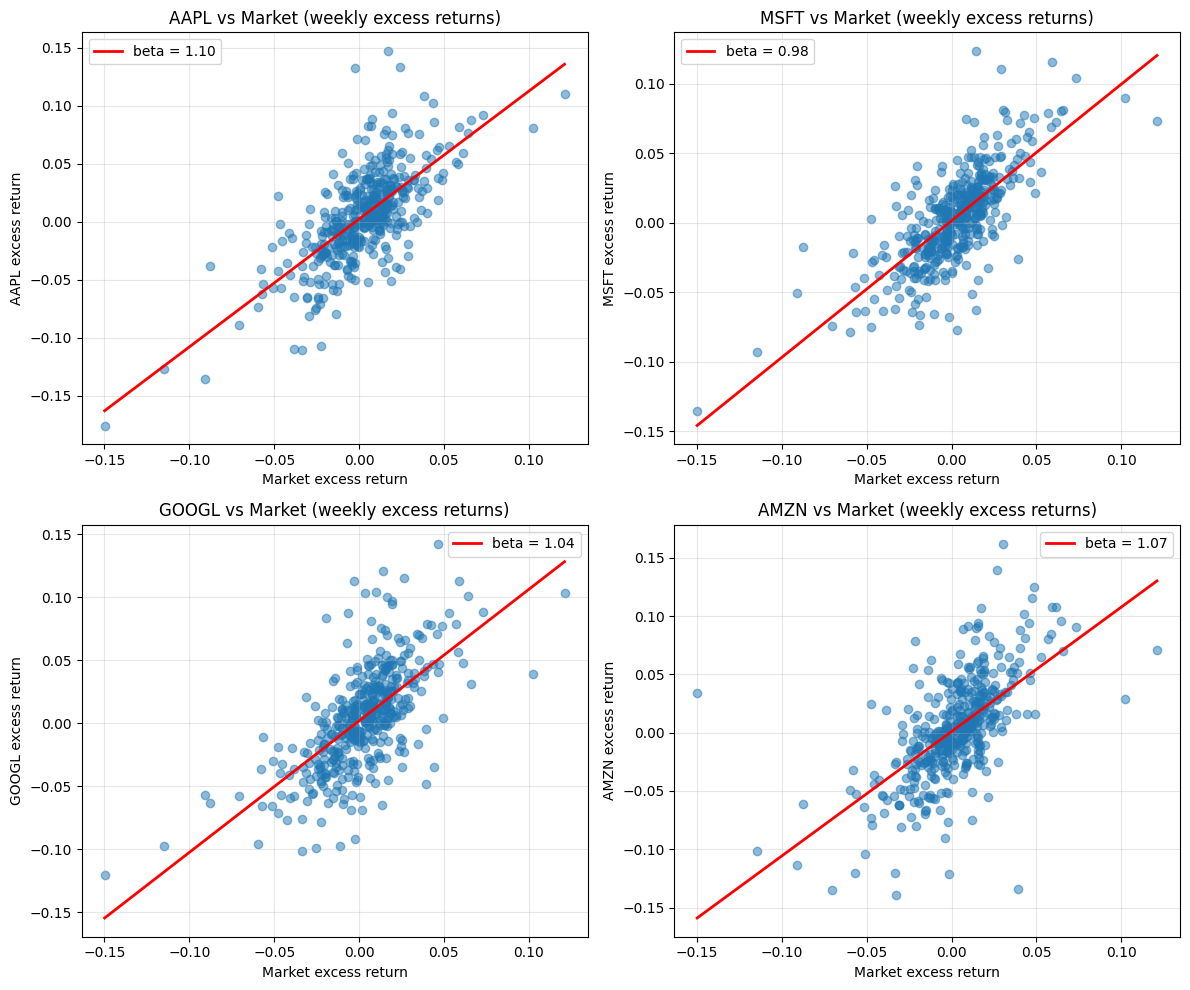

In [ ]:
# Beginner guide:
# - Purpose: visualize CAPM regressions for selected stocks.
# - Each scatter plot compares weekly stock excess return (y) to market excess return (x).
# - The red line uses estimated `alpha_weekly` and `beta` from `capm_results`.
# - Slope interpretation: higher beta means stronger sensitivity to market movements.
# --- Beta visuals: CAPM regression scatter plots (weekly excess returns) ---
# In each panel:
# x-axis: market excess return (R_M - R_f)
# y-axis: stock excess return (R_i - R_f)
# red line: fitted CAPM line, whose slope is beta

def plot_scatter_with_capm_line(stock_excess, market_excess, ticker, ax, alpha_weekly, beta_hat):
    """Scatter of stock vs market excess returns with CAPM fitted line."""
    df = (
        stock_excess.rename("y").to_frame()
        .join(market_excess.rename("x"), how="inner")
        .dropna()
    )

    x = df["x"].values
    y = df["y"].values

    ax.scatter(x, y, alpha=0.5)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = alpha_weekly + beta_hat * x_line
    ax.plot(x_line, y_line, color="red", linewidth=2, label=f"beta = {beta_hat:.2f}")

    ax.set_title(f"{ticker} vs Market (weekly excess returns)")
    ax.set_xlabel("Market excess return")
    ax.set_ylabel(f"{ticker} excess return")
    ax.grid(alpha=0.3)
    ax.legend()

plot_tickers = ["AAPL", "MSFT", "GOOGL", "AMZN"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, ticker in zip(axes, plot_tickers):
    alpha_weekly = float(capm_results.loc[ticker, "alpha_weekly"])
    beta_hat = float(capm_results.loc[ticker, "beta"])
    plot_scatter_with_capm_line(stk_excess[ticker], mkt_excess, ticker, ax, alpha_weekly, beta_hat)

plt.tight_layout()
plt.show()